# Visual MCQ Solver — Google Colab Version

**Before running:**
1. Go to `Runtime → Change runtime type → GPU (T4)`
2. Run cells top to bottom in order
3. Internet must be ON (Colab default)

**Pipeline:**  
`PNG image → Phi-3.5-Vision (VLM) → Predicted answer letter (A/B/C/D)`

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Check GPU                                             ║
# ╚══════════════════════════════════════════════════════════════════╝
import torch

if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    print(f'GPU  : {gpu.name}')
    print(f'VRAM : {gpu.total_memory / 1e9:.1f} GB')


else:
    print('WARNING: No GPU detected. Go to Runtime > Change runtime type > GPU')


GPU  : Tesla T4
VRAM : 15.6 GB


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — Install packages                                      ║
# ╚══════════════════════════════════════════════════════════════════╝
!pip install -q transformers==4.43.4 accelerate einops huggingface_hub pillow pandas
print('All packages installed.')


All packages installed.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Mount Google Drive                                    ║
# ╚══════════════════════════════════════════════════════════════════╝
import os
USE_DRIVE = True

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    MODEL_CACHE = '/content/drive/MyDrive/models/phi35-vision'
    print(f'Drive mounted. Model will be saved/loaded from: {MODEL_CACHE}')
else:
    MODEL_CACHE = '/content/phi35-vision'
    print(f'Drive skipped. Model saved locally at: {MODEL_CACHE}')
    print('NOTE: Model will re-download every Colab session.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Model will be saved/loaded from: /content/drive/MyDrive/models/phi35-vision


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — Download model from HuggingFace                       ║
# ╚══════════════════════════════════════════════════════════════════╝
import os
from huggingface_hub import snapshot_download

MODEL_REPO = 'microsoft/Phi-3.5-vision-instruct'

if os.path.exists(os.path.join(MODEL_CACHE, 'config.json')):
    print(f'Model already downloaded at {MODEL_CACHE}. Skipping download.')
else:
    print(f'Downloading {MODEL_REPO} ...')
    print('This takes ~5-10 minutes for first download (~8 GB)')
    os.makedirs(MODEL_CACHE, exist_ok=True)
    snapshot_download(
        repo_id=MODEL_REPO,
        local_dir=MODEL_CACHE,
        ignore_patterns=['*.bin', 'original/*']
    )
    print('Download complete!')


Model already downloaded at /content/drive/MyDrive/models/phi35-vision. Skipping download.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 4.5 — Compatibility patch for transformers 4.43+          ║
# ╚══════════════════════════════════════════════════════════════════╝
import glob, os

# --- Patch 1: Fix DynamicCache.seen_tokens for all transformers versions ---
from transformers.cache_utils import DynamicCache

if not hasattr(DynamicCache, 'seen_tokens'):
    def _seen_tokens_compat(self):
        # transformers 5.x removed seen_tokens; get_seq_length() is the replacement
        if hasattr(self, '_seen_tokens'):
            return self._seen_tokens
        return self.get_seq_length()
    DynamicCache.seen_tokens = property(_seen_tokens_compat)
    print('Patch 1 applied: DynamicCache.seen_tokens')
else:
    print('Patch 1 not needed.')

# --- Patch 2: Fix the cached model file directly (most reliable fix) -------
search_patterns = [
    '/root/.cache/huggingface/modules/transformers_modules/**/modeling_phi3_v.py',
    os.path.expanduser('~/.cache/huggingface/modules/transformers_modules/**/modeling_phi3_v.py'),
]

patched_file = False
for pattern in search_patterns:
    for fpath in glob.glob(pattern, recursive=True):
        with open(fpath, 'r') as f:
            content = f.read()
        if 'past_key_values.seen_tokens' in content:
            content = content.replace(
                'past_key_values.seen_tokens',
                '(past_key_values.get_seq_length() if hasattr(past_key_values, "get_seq_length") else past_key_values._seen_tokens)'
            )
            with open(fpath, 'w') as f:
                f.write(content)
            print(f'Patch 2 applied: {fpath}')
            patched_file = True
        else:
            print(f'Patch 2 not needed: {fpath}')
            patched_file = True

if not patched_file:
    print('Patch 2: model file not found yet (will apply after model download if needed).')

print('\nAll patches done.')


Patch 1 not needed.
Patch 2 not needed: /root/.cache/huggingface/modules/transformers_modules/phi35-vision/modeling_phi3_v.py
Patch 2 not needed: /root/.cache/huggingface/modules/transformers_modules/phi35_hyphen_vision/modeling_phi3_v.py
Patch 2 not needed: /root/.cache/huggingface/modules/transformers_modules/phi35-vision/modeling_phi3_v.py
Patch 2 not needed: /root/.cache/huggingface/modules/transformers_modules/phi35_hyphen_vision/modeling_phi3_v.py

All patches done.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Load model into GPU memory                            ║
# ╚══════════════════════════════════════════════════════════════════╝
import warnings, re, os, glob
import torch
from PIL import Image
from transformers import AutoModelForCausalLM, AutoProcessor
from transformers.cache_utils import DynamicCache

warnings.filterwarnings('ignore')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Re-apply DynamicCache patch here as safety (in case Cell 4.5 was skipped)
if not hasattr(DynamicCache, 'seen_tokens'):
    DynamicCache.seen_tokens = property(
        lambda self: self.get_seq_length() if hasattr(self, 'get_seq_length') else self._seen_tokens
    )

print('Loading processor...')
processor = AutoProcessor.from_pretrained(
    MODEL_CACHE,
    trust_remote_code=True,
    num_crops=4
)

print('Loading model into GPU... (~1 min)')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_CACHE,
    trust_remote_code=True,
    torch_dtype=torch.float16,
    device_map='auto',
    _attn_implementation='eager'
)
model.eval()

# Patch the now-loaded model module directly (covers edge cases)
search_patterns = [
    '/root/.cache/huggingface/modules/transformers_modules/**/modeling_phi3_v.py',
    os.path.expanduser('~/.cache/huggingface/modules/transformers_modules/**/modeling_phi3_v.py'),
]
for pattern in search_patterns:
    for fpath in glob.glob(pattern, recursive=True):
        with open(fpath, 'r') as f:
            content = f.read()
        if 'past_key_values.seen_tokens' in content:
            content = content.replace(
                'past_key_values.seen_tokens',
                '(past_key_values.get_seq_length() if hasattr(past_key_values, "get_seq_length") else past_key_values._seen_tokens)'
            )
            with open(fpath, 'w') as f:
                f.write(content)
            print(f'Model file patched: {fpath}')

print(f'\nModel loaded on: {DEVICE}')
print(f'VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB')


Loading processor...
Loading model into GPU... (~1 min)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model file patched: /root/.cache/huggingface/modules/transformers_modules/phi35-vision/modeling_phi3_v.py

Model loaded on: cuda
VRAM used: 8.29 GB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — Define solve_mcq() function                           ║
# ╚══════════════════════════════════════════════════════════════════╝
import re
import torch
from PIL import Image

SYSTEM_PROMPT = (
    'You are an expert professor in deep learning and machine learning. '
    'You have extensive knowledge of neural networks, CNNs, RNNs, transformers, '
    'optimization algorithms, regularization, backpropagation, and all related topics. '
    'You always answer multiple choice questions correctly.'
)

USER_PROMPT = (
    '<|image_1|>\n'
    'This image contains a multiple choice question about deep learning. '
    'Read the question and all 4 options carefully. '
    'Based on your deep learning expertise, identify the correct answer. '
    'Respond with ONLY a single letter: A, B, C, or D. No explanation.'
)


def solve_mcq(image_path: str) -> str:
    image = Image.open(image_path).convert('RGB')

    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user',   'content': USER_PROMPT}
    ]

    prompt = processor.tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    inputs = processor(prompt, images=[image], return_tensors='pt').to(DEVICE)

    with torch.no_grad():
        generate_ids = model.generate(
            **inputs,
            max_new_tokens=5,
            do_sample=False,
            eos_token_id=processor.tokenizer.eos_token_id,
            use_cache=True,
        )

    new_tokens = generate_ids[:, inputs['input_ids'].shape[1]:]
    raw = processor.batch_decode(
        new_tokens,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0].strip()

    match = re.search(r'\b([A-D])\b', raw.upper())
    return match.group(1) if match else 'A'


print('solve_mcq() ready.')


solve_mcq() ready.


---
## Choose your test image source — run ONE of the cells below (Cell 7a OR 7b)

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 7a — Upload images manually from your computer            ║
# ╚══════════════════════════════════════════════════════════════════╝
import os
from google.colab import files

TEST_DIR = '/content/test_images'
os.makedirs(TEST_DIR, exist_ok=True)

print('A file picker will appear. Select all your PNG images.')
uploaded = files.upload()

for fname, data in uploaded.items():
    dest = os.path.join(TEST_DIR, fname)
    with open(dest, 'wb') as f:
        f.write(data)

imgs = sorted([f for f in os.listdir(TEST_DIR) if f.endswith('.png')])
print(f'Uploaded {len(imgs)} images to {TEST_DIR}')


A file picker will appear. Select all your PNG images.


Saving image_1.png to image_1 (2).png
Saving image_2.png to image_2 (2).png
Uploaded 17 images to /content/test_images


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 7b — Upload images as a ZIP file                          ║
# ╚══════════════════════════════════════════════════════════════════╝
import os, glob, zipfile
from google.colab import files

TEST_DIR = '/content/test_images'
os.makedirs(TEST_DIR, exist_ok=True)

print('Upload the mcq_images.zip file')
uploaded = files.upload()

for fname in uploaded:
    if fname.endswith('.zip'):
        with zipfile.ZipFile(fname, 'r') as z:
            z.extractall(TEST_DIR)
        print(f'Extracted {fname} to {TEST_DIR}')

all_images = sorted(glob.glob(os.path.join(TEST_DIR, '**/*.png'), recursive=True))
print(f'Found {len(all_images)} PNG images.')


The `seen_tokens` attribute is deprecated and will be removed in v4.41. Use the `cache_position` model input instead.


image_1 (1).png  =>  A
image_1 (2).png  =>  A
image_2 (1).png  =>  D


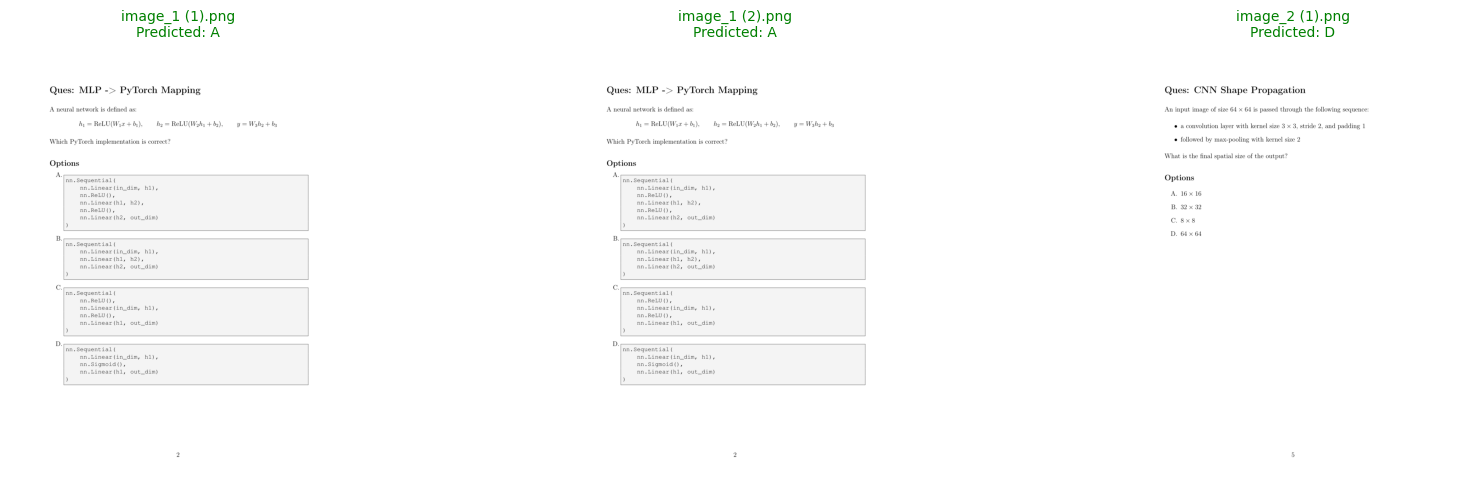

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — Quick test on 3 images (sanity check)                 ║
# ╚══════════════════════════════════════════════════════════════════╝
import os, glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

sample_paths = sorted(glob.glob(os.path.join(TEST_DIR, '**/*.png'), recursive=True))[:3]

if not sample_paths:
    print('No images found. Run Cell 7a or 7b first.')
else:
    fig, axes = plt.subplots(1, len(sample_paths), figsize=(18, 5))
    if len(sample_paths) == 1:
        axes = [axes]

    for ax, img_path in zip(axes, sample_paths):
        answer = solve_mcq(img_path)
        fname  = os.path.basename(img_path)
        img    = mpimg.imread(img_path)
        ax.imshow(img)
        ax.set_title(f'{fname}\nPredicted: {answer}', fontsize=10, color='green')
        ax.axis('off')
        print(f'{fname}  =>  {answer}')

    plt.tight_layout()
    plt.show()


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — Run inference on ALL test images                      ║
# ╚══════════════════════════════════════════════════════════════════╝
import os, glob
import pandas as pd
from tqdm.notebook import tqdm

all_images = sorted(glob.glob(os.path.join(TEST_DIR, '**/*.png'), recursive=True))
print(f'Running inference on {len(all_images)} images...\n')

records = []
for img_path in tqdm(all_images, desc='Solving MCQs'):
    image_id = os.path.splitext(os.path.basename(img_path))[0]
    answer   = solve_mcq(img_path)
    records.append({'id': image_id, 'answer': answer})

print('\nInference complete.')


Running inference on 17 images...



Solving MCQs:   0%|          | 0/17 [00:00<?, ?it/s]


Inference complete.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — Save submission.csv and download it                  ║
# ╚══════════════════════════════════════════════════════════════════╝
import pandas as pd
from google.colab import files as colab_files

SUBMISSION_PATH = '/content/submission.csv'

submission = pd.DataFrame(records)
submission.to_csv(SUBMISSION_PATH, index=False)

print(f'Saved {len(submission)} predictions.')
print('\nAnswer distribution:')
print(submission['answer'].value_counts().sort_index().to_string())
print()
print('First 10 rows:')
display(submission.head(10))

colab_files.download(SUBMISSION_PATH)
print('\nsubmission.csv downloaded to your computer.')


Saved 17 predictions.

Answer distribution:
answer
A    11
B     4
D     2

First 10 rows:


,id,answer
0,image_1 (1),A
1,image_1 (2),A
2,image_2 (1),D
3,image_2 (2),D
4,q048 (1),B
5,q048,B
6,q049 (1),B
7,q049,B
8,q050 (1),A
9,q050,A


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


submission.csv downloaded to your computer.


In [ ]:
 # ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — (OPTIONAL) Evaluate accuracy if you have labels      ║
# ╚══════════════════════════════════════════════════════════════════╝
import pandas as pd
from google.colab import files as colab_files

print('Upload your ground_truth.csv file (columns: id, answer)')
uploaded = colab_files.upload()

for fname, data in uploaded.items():
    with open(f'/content/{fname}', 'wb') as f:
        f.write(data)
    gt_path = f'/content/{fname}'

gt     = pd.read_csv(gt_path)
merged = gt.merge(submission, on='id', suffixes=('_true', '_pred'))
correct = (merged['answer_true'] == merged['answer_pred']).sum()
total   = len(merged)
acc     = correct / total

print(f'\nAccuracy : {acc:.2%}  ({correct}/{total})')
print('\nPer-answer breakdown:')
print(merged.groupby('answer_true')['answer_pred'].apply(
    lambda x: f'{(x == x.name).sum()}/{len(x)}'
).to_string())


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 12 — (OPTIONAL) Majority voting for higher accuracy       ║
# ╚══════════════════════════════════════════════════════════════════╝
import os, glob, re
import torch
import pandas as pd
from PIL import Image
from collections import Counter
from tqdm.notebook import tqdm
from google.colab import files as colab_files

N_VOTES = 5

def solve_mcq_vote(image_path: str, n_votes: int = N_VOTES) -> str:
    image = Image.open(image_path).convert('RGB')
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user',   'content': USER_PROMPT}
    ]
    prompt = processor.tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = processor(prompt, images=[image], return_tensors='pt').to(DEVICE)

    votes = []
    for _ in range(n_votes):
        with torch.no_grad():
            ids = model.generate(
                **inputs, max_new_tokens=5,
                do_sample=True, temperature=0.3, top_p=0.9,
                eos_token_id=processor.tokenizer.eos_token_id,
                use_cache=True,
            )
        raw = processor.batch_decode(
            ids[:, inputs['input_ids'].shape[1]:],
            skip_special_tokens=True
        )[0].strip()
        m = re.search(r'\b([A-D])\b', raw.upper())
        votes.append(m.group(1) if m else 'A')

    return Counter(votes).most_common(1)[0][0]


all_images = sorted(glob.glob(os.path.join(TEST_DIR, '**/*.png'), recursive=True))
print(f'Running majority-vote ({N_VOTES}x) on {len(all_images)} images...')

records_vote = []
for img_path in tqdm(all_images, desc='Majority Vote'):
    image_id = os.path.splitext(os.path.basename(img_path))[0]
    answer   = solve_mcq_vote(img_path)
    records_vote.append({'id': image_id, 'answer': answer})

submission_vote = pd.DataFrame(records_vote)
submission_vote.to_csv('/content/submission_voted.csv', index=False)
colab_files.download('/content/submission_voted.csv')
print('submission_voted.csv downloaded.')


---
## Troubleshooting

| Problem | Fix |
|---------|-----|
| `CUDA out of memory` | Runtime → Disconnect and reconnect, then re-run. Or use `torch_dtype=torch.float32` (slower) |
| All predictions are `A` | The model may not be reading the image. Check image path and ensure it is a valid RGB PNG |
| `ModuleNotFoundError: transformers` | Re-run Cell 2 |
| Drive not mounting | Refresh page, allow Google Drive permissions popup |
| Download too slow | Use `Qwen2-VL-2B-Instruct` (smaller, faster) by changing `MODEL_REPO` in Cell 4 |

---
# Visual MCQ Solver — Qwen2-VL-2B-Instruct Version

**Model:** `Qwen/Qwen2-VL-2B-Instruct` (2B params, faster, no compatibility patches needed)

**Pipeline:**  
`PNG image → Qwen2-VL-2B (VLM) → Predicted answer letter (A/B/C/D)`

**Before running:**
1. Runtime must already have a GPU (T4 from above section is fine)
2. Run cells Q1 → Q12 in order
3. You can run this section independently — it uses its own model cache and variable names


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL Q1 — Check GPU                                            ║
# ╚══════════════════════════════════════════════════════════════════╝
import torch

if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    print(f'GPU  : {gpu.name}')
    print(f'VRAM : {gpu.total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU detected. Go to Runtime > Change runtime type > GPU')


GPU  : Tesla T4
VRAM : 15.6 GB


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL Q2 — Install packages for Qwen2-VL                        ║
# ║  Qwen2VLForConditionalGeneration requires transformers >= 4.45   ║
# ╚══════════════════════════════════════════════════════════════════╝
import subprocess, sys

# Upgrade transformers to a version that includes Qwen2-VL support
!pip install -q "transformers>=4.45.0" accelerate qwen-vl-utils pillow pandas huggingface_hub

# Verify the installed version
import importlib
import transformers
importlib.reload(transformers)
print(f'transformers version : {transformers.__version__}')

# Confirm Qwen2-VL class is available
try:
    from transformers import Qwen2VLForConditionalGeneration
    print('Qwen2VLForConditionalGeneration : OK')
except ImportError:
    print('Still not found — please go to Runtime > Restart runtime, then re-run from Cell Q2.')

print('\nAll packages installed.')


transformers version : 5.5.4
Qwen2VLForConditionalGeneration : OK

All packages installed.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL Q3 — Mount Google Drive                                   ║
# ╚══════════════════════════════════════════════════════════════════╝
import os

USE_DRIVE_Q = True   # Set False to skip Drive mounting

if USE_DRIVE_Q:
    from google.colab import drive
    drive.mount('/content/drive')
    MODEL_CACHE_Q = '/content/drive/MyDrive/models/qwen2-vl-2b'
    print(f'Drive mounted. Model will be saved/loaded from: {MODEL_CACHE_Q}')
else:
    MODEL_CACHE_Q = '/content/qwen2-vl-2b'
    print(f'Drive skipped. Model saved locally at: {MODEL_CACHE_Q}')
    print('NOTE: Model will re-download every Colab session.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Model will be saved/loaded from: /content/drive/MyDrive/models/qwen2-vl-2b


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL Q4 — Download Qwen2-VL-2B model from HuggingFace          ║
# ║           Skips download if already saved to Drive               ║
# ╚══════════════════════════════════════════════════════════════════╝
import os
from huggingface_hub import snapshot_download

MODEL_REPO_Q = 'Qwen/Qwen2-VL-2B-Instruct'

if os.path.exists(os.path.join(MODEL_CACHE_Q, 'config.json')):
    print(f'Model already downloaded at {MODEL_CACHE_Q}. Skipping download.')
else:
    print(f'Downloading {MODEL_REPO_Q} ...')
    print('This takes ~2-4 minutes (~4.5 GB)')
    os.makedirs(MODEL_CACHE_Q, exist_ok=True)
    snapshot_download(
        repo_id=MODEL_REPO_Q,
        local_dir=MODEL_CACHE_Q,
        ignore_patterns=['*.bin', 'original/*']   # safetensors only
    )
    print('Download complete!')


Model already downloaded at /content/drive/MyDrive/models/qwen2-vl-2b. Skipping download.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL Q5 — Load Qwen2-VL model into GPU memory                  ║
# ║           No compatibility patches needed for this model         ║
# ╚══════════════════════════════════════════════════════════════════╝
import warnings
import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

warnings.filterwarnings('ignore')
DEVICE_Q = 'cuda' if torch.cuda.is_available() else 'cpu'

print('Loading Qwen2-VL processor...')
processor_q = AutoProcessor.from_pretrained(
    MODEL_CACHE_Q,
    min_pixels=256 * 28 * 28,
    max_pixels=1280 * 28 * 28
)

print('Loading Qwen2-VL model into GPU... (~1 min)')
model_q = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_CACHE_Q,
    torch_dtype=torch.float16,
    device_map='auto'
)
model_q.eval()

print(f'Model loaded on : {DEVICE_Q}')
print(f'VRAM used       : {torch.cuda.memory_allocated()/1e9:.2f} GB')
print(f'generate() ok   : {hasattr(model_q, "generate")}')


Loading Qwen2-VL processor...
Loading Qwen2-VL model into GPU... (~1 min)


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Model loaded on : cuda
VRAM used       : 4.43 GB
generate() ok   : True


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL Q6 — Define solve_mcq_qwen() function                     ║
# ╚══════════════════════════════════════════════════════════════════╝
import re
import torch
from PIL import Image
from qwen_vl_utils import process_vision_info

QWEN_QUESTION = (
    'This image contains a multiple choice question about deep learning. '
    'Read the question and all 4 options carefully. '
    'Based on your deep learning expertise, identify the correct answer. '
    'Respond with ONLY a single letter: A, B, C, or D. No explanation.'
)


def solve_mcq_qwen(image_path: str) -> str:
    """
    Takes path to a PNG MCQ image.
    Returns predicted answer letter: A, B, C, or D.
    Uses Qwen2-VL-2B-Instruct model.
    """
    messages = [
        {
            'role': 'user',
            'content': [
                {'type': 'image', 'image': image_path},
                {'type': 'text',  'text': QWEN_QUESTION}
            ]
        }
    ]

    # Build text prompt using Qwen chat template
    text_prompt = processor_q.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    # Extract image inputs using Qwen's utility
    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor_q(
        text=[text_prompt],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors='pt'
    ).to(DEVICE_Q)

    with torch.no_grad():
        generated_ids = model_q.generate(
            **inputs,
            max_new_tokens=5,
            do_sample=False
        )

    # Trim input tokens — keep only newly generated tokens
    trimmed_ids = [
        out[len(inp):]
        for inp, out in zip(inputs.input_ids, generated_ids)
    ]

    raw = processor_q.batch_decode(
        trimmed_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0].strip()

    match = re.search(r'\b([A-D])\b', raw.upper())
    return match.group(1) if match else 'A'


print('solve_mcq_qwen() ready.')


solve_mcq_qwen() ready.


---
## Choose your test image source — run ONE of the cells below (Cell Q7a OR Q7b)


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL Q7a — Upload images manually from your computer           ║
# ╚══════════════════════════════════════════════════════════════════╝
import os
from google.colab import files

TEST_DIR_Q = '/content/test_images_qwen'
os.makedirs(TEST_DIR_Q, exist_ok=True)

print('A file picker will appear. Select all your PNG images.')
uploaded = files.upload()

for fname, data in uploaded.items():
    dest = os.path.join(TEST_DIR_Q, fname)
    with open(dest, 'wb') as f:
        f.write(data)

imgs = sorted([f for f in os.listdir(TEST_DIR_Q) if f.endswith('.png')])
print(f'Uploaded {len(imgs)} images to {TEST_DIR_Q}')


A file picker will appear. Select all your PNG images.


Saving image_1.png to image_1.png
Saving image_2.png to image_2.png
Uploaded 9 images to /content/test_images_qwen


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL Q7b — Upload images as a ZIP file                         ║
# ╚══════════════════════════════════════════════════════════════════╝
import os, glob, zipfile
from google.colab import files

TEST_DIR_Q = '/content/test_images_qwen'
os.makedirs(TEST_DIR_Q, exist_ok=True)

print('Upload the mcq_images.zip file')
uploaded = files.upload()

for fname in uploaded:
    if fname.endswith('.zip'):
        with zipfile.ZipFile(fname, 'r') as z:
            z.extractall(TEST_DIR_Q)
        print(f'Extracted {fname} to {TEST_DIR_Q}')

all_images_q = sorted(glob.glob(os.path.join(TEST_DIR_Q, '**/*.png'), recursive=True))
print(f'Found {len(all_images_q)} PNG images.')


image_1.png  =>  B
image_2.png  =>  B
q048 (1).png  =>  B


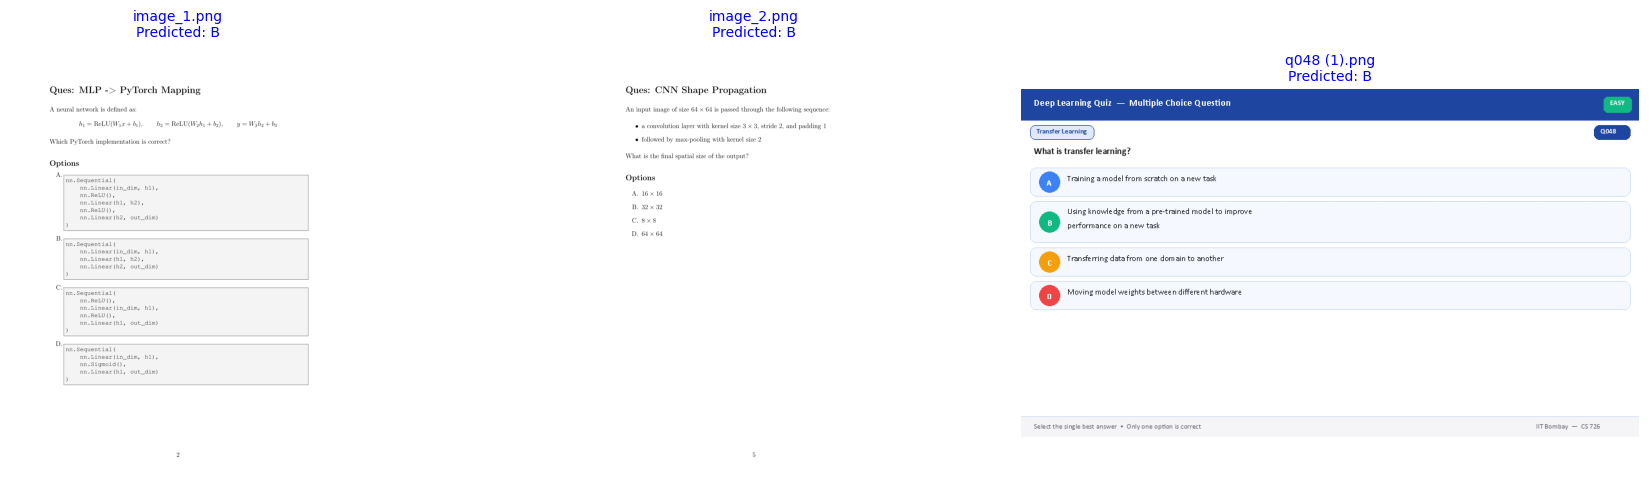

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL Q8 — Quick test on 3 images (sanity check)                ║
# ╚══════════════════════════════════════════════════════════════════╝
import os, glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

sample_paths_q = sorted(glob.glob(os.path.join(TEST_DIR_Q, '**/*.png'), recursive=True))[:3]

if not sample_paths_q:
    print('No images found. Run Cell Q7a or Q7b first.')
else:
    fig, axes = plt.subplots(1, len(sample_paths_q), figsize=(18, 5))
    if len(sample_paths_q) == 1:
        axes = [axes]

    for ax, img_path in zip(axes, sample_paths_q):
        answer = solve_mcq_qwen(img_path)
        fname  = os.path.basename(img_path)
        img    = mpimg.imread(img_path)
        ax.imshow(img)
        ax.set_title(f'{fname}\nPredicted: {answer}', fontsize=10, color='blue')
        ax.axis('off')
        print(f'{fname}  =>  {answer}')

    plt.tight_layout()
    plt.show()


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL Q9 — Run inference on ALL test images                     ║
# ╚══════════════════════════════════════════════════════════════════╝
import os, glob
import pandas as pd
from tqdm.notebook import tqdm

all_images_q = sorted(glob.glob(os.path.join(TEST_DIR_Q, '**/*.png'), recursive=True))
print(f'Running inference on {len(all_images_q)} images...\n')

records_q = []
for img_path in tqdm(all_images_q, desc='Solving MCQs (Qwen)'):
    image_id = os.path.splitext(os.path.basename(img_path))[0]
    answer   = solve_mcq_qwen(img_path)
    records_q.append({'id': image_id, 'answer': answer})

print('\nInference complete.')


Running inference on 7 images...



Solving MCQs (Qwen):   0%|          | 0/7 [00:00<?, ?it/s]


Inference complete.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL Q10 — Save submission_qwen.csv and download it            ║
# ╚══════════════════════════════════════════════════════════════════╝
import pandas as pd
from google.colab import files as colab_files

SUBMISSION_PATH_Q = '/content/submission_qwen.csv'

submission_q = pd.DataFrame(records_q)
submission_q.to_csv(SUBMISSION_PATH_Q, index=False)

print(f'Saved {len(submission_q)} predictions.')
print('\nAnswer distribution:')
print(submission_q['answer'].value_counts().sort_index().to_string())
print()
print('First 10 rows:')
display(submission_q.head(10))

colab_files.download(SUBMISSION_PATH_Q)
print('\nsubmission_qwen.csv downloaded to your computer.')


Saved 7 predictions.

Answer distribution:
answer
A    1
B    6

First 10 rows:


,id,answer
0,q048 (1),B
1,q049 (1),B
2,q050 (1),B
3,q051 (1),B
4,q052 (1),B
5,q053 (1),A
6,q054 (1),B


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


submission_qwen.csv downloaded to your computer.


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL Q11 — (OPTIONAL) Evaluate accuracy if you have labels     ║
# ╚══════════════════════════════════════════════════════════════════╝
import pandas as pd
from google.colab import files as colab_files

print('Upload your ground_truth.csv file (columns: id, answer)')
uploaded = colab_files.upload()

for fname, data in uploaded.items():
    with open(f'/content/{fname}', 'wb') as f:
        f.write(data)
    gt_path_q = f'/content/{fname}'

gt_q    = pd.read_csv(gt_path_q)
merged_q = gt_q.merge(submission_q, on='id', suffixes=('_true', '_pred'))
correct  = (merged_q['answer_true'] == merged_q['answer_pred']).sum()
total    = len(merged_q)
acc      = correct / total

print(f'\nAccuracy : {acc:.2%}  ({correct}/{total})')
print('\nPer-answer breakdown:')
print(merged_q.groupby('answer_true')['answer_pred'].apply(
    lambda x: f'{(x == x.name).sum()}/{len(x)}'
).to_string())


In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL Q12 — (OPTIONAL) Majority voting for higher accuracy      ║
# ║             Warning: ~5x slower                                  ║
# ╚══════════════════════════════════════════════════════════════════╝
import os, glob, re
import torch
import pandas as pd
from collections import Counter
from tqdm.notebook import tqdm
from google.colab import files as colab_files
from qwen_vl_utils import process_vision_info

N_VOTES_Q = 5


def solve_mcq_qwen_vote(image_path: str, n_votes: int = N_VOTES_Q) -> str:
    messages = [
        {
            'role': 'user',
            'content': [
                {'type': 'image', 'image': image_path},
                {'type': 'text',  'text': QWEN_QUESTION}
            ]
        }
    ]

    text_prompt   = processor_q.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor_q(
        text=[text_prompt],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors='pt'
    ).to(DEVICE_Q)

    votes = []
    for _ in range(n_votes):
        with torch.no_grad():
            ids = model_q.generate(
                **inputs,
                max_new_tokens=5,
                do_sample=True,
                temperature=0.3,
                top_p=0.9
            )
        trimmed = [out[len(inp):] for inp, out in zip(inputs.input_ids, ids)]
        raw = processor_q.batch_decode(
            trimmed, skip_special_tokens=True
        )[0].strip()
        m = re.search(r'\b([A-D])\b', raw.upper())
        votes.append(m.group(1) if m else 'A')

    return Counter(votes).most_common(1)[0][0]


all_images_q = sorted(glob.glob(os.path.join(TEST_DIR_Q, '**/*.png'), recursive=True))
print(f'Running majority-vote ({N_VOTES_Q}x) on {len(all_images_q)} images...')

records_vote_q = []
for img_path in tqdm(all_images_q, desc='Majority Vote (Qwen)'):
    image_id = os.path.splitext(os.path.basename(img_path))[0]
    answer   = solve_mcq_qwen_vote(img_path)
    records_vote_q.append({'id': image_id, 'answer': answer})

submission_vote_q = pd.DataFrame(records_vote_q)
submission_vote_q.to_csv('/content/submission_qwen_voted.csv', index=False)
colab_files.download('/content/submission_qwen_voted.csv')
print('submission_qwen_voted.csv downloaded.')


---
## Troubleshooting (Qwen2-VL)

| Problem | Fix |
|---------|-----|
| `CUDA out of memory` | Runtime → Disconnect and reconnect, then re-run. Qwen2-VL-2B uses ~6 GB VRAM so T4 should be fine |
| `ModuleNotFoundError: qwen_vl_utils` | Re-run Cell Q2 |
| `No module named transformers.models.qwen2_vl` | Upgrade transformers: `pip install -q --upgrade transformers` then restart runtime |
| All predictions are `A` | Check image path is correct and image is a valid RGB PNG |
| Want higher accuracy | Switch to `Qwen/Qwen2-VL-7B-Instruct` in Cell Q4 (needs more VRAM ~14 GB) |
| Drive not mounting | Refresh page and allow Google Drive permissions popup |
